In [30]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
import struct
from pathlib import Path
from scipy.stats import skew, kurtosis

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')


Using device: cpu


In [31]:
class PipeDataset(Dataset):
    def __init__(self, data_list, labels, scaler=None, fit_scaler=False):
        self.data_list = data_list
        self.labels = labels
        if fit_scaler:
            all_data = np.vstack(data_list)
            self.scaler = StandardScaler().fit(all_data)
        else:
            self.scaler = scaler
        self.data_list = [torch.FloatTensor(self.scaler.transform(sample)) for sample in self.data_list]
        self.labels = torch.LongTensor(labels)
    def __len__(self):
        return len(self.data_list)
    def __getitem__(self, idx):
        return self.data_list[idx], self.labels[idx]

def collate_fn(batch):
    data_list, labels = zip(*batch)
    max_len = max([d.shape[0] for d in data_list])
    padded_data, lengths = [], []
    for data in data_list:
        length = data.shape[0]
        lengths.append(length)
        padding = torch.zeros(max_len - length, data.shape[1])
        padded = torch.cat([data, padding], dim=0)
        padded_data.append(padded)
    data_batch = torch.stack(padded_data)
    labels_batch = torch.stack(labels)
    mask = torch.zeros(data_batch.shape[:2])
    for i, length in enumerate(lengths):
        mask[i, :length] = 1
    return data_batch, labels_batch, mask, torch.tensor(lengths)


In [39]:
class PipeCNNEncoder(nn.Module):
    def __init__(self, input_channels=8, embedding_dim=64):
        super().__init__()
        self.stem = nn.Sequential(nn.Conv1d(input_channels, 32, 9, padding=4), nn.BatchNorm1d(32), nn.ReLU())
        self.block = nn.Sequential(nn.Conv1d(32, 64, 5, padding=2), nn.BatchNorm1d(64), nn.ReLU())
        self.attention = nn.Sequential(nn.Conv1d(64, 32, 1), nn.ReLU(), nn.Conv1d(32, 1, 1))
    def forward(self, x):
        x = x.transpose(1, 2)
        x = self.stem(x)
        x = self.block(x)
        w = self.attention(x)
        w = torch.softmax(w, dim=2)
        x = (x * w).sum(dim=2)
        return x


In [40]:
def read_raw_file(filepath):
    path = Path(filepath)
    if not path.exists():
        raise FileNotFoundError(f'File not found: {path}')
    with open(path, 'rb') as f:
        data = f.read()
    if len(data) < 17:
        raise ValueError('File too short')
    x = struct.unpack_from('>i', data, 0)[0]
    y = struct.unpack_from('>i', data, 4)[0]
    thicknom = struct.unpack_from('>d', data, 8)[0]
    defective = struct.unpack_from('>B', data, 16)[0]
    num_values = x * y
    matrix = struct.unpack(f'>{num_values}d', data[17:17+num_values*8])
    matrix_np = np.array(matrix, dtype=np.float32).reshape(x, y)
    return {'matrix': matrix_np, 'defective': defective, 'thicknom': thicknom}

def load_dataset_from_folder(folder_path, verbose=True):
    folder = Path(folder_path)
    raw_files = list(folder.glob('*.raw'))
    if not raw_files:
        raise FileNotFoundError(f'No .raw files found in {folder_path}')
    if verbose:
        print(f'Found files: {len(raw_files)}')
    data_list, labels, thicknom_list = [], [], []
    for file_path in raw_files:
        try:
            result = read_raw_file(file_path)
            data_list.append(result['matrix'])
            labels.append(result['defective'])
            thicknom_list.append(result['thicknom'])
        except Exception as e:
            print(f'Error reading {file_path.name}: {e}')
    if verbose:
        print(f'Loaded: {len(data_list)} files')
    return data_list, np.array(labels), thicknom_list


In [41]:
def extract_features(matrix, thicknom):
    m = matrix.copy()
    mask = m > 0
    if mask.any():
        rows = np.where(mask.any(axis=1))[0]
        m = m[rows[0]:rows[-1]+1]
    m = m / thicknom
    features = []
    flat = m.flatten()
    features += [flat.min(), flat.max(), flat.mean(), flat.std(), skew(flat), kurtosis(flat)]
    for col in range(m.shape[1]):
        col_data = m[:, col]
        features += [col_data.mean(), col_data.std(), col_data.max() - col_data.min()]
    for row in range(min(10, m.shape[0])):
        row_data = m[row, :]
        features += [row_data.mean(), row_data.std()]
    return np.array(features, dtype=np.float32)

def build_feature_dataset(data_list, labels, thicknom_list):
    features = [extract_features(matrix, thicknom) for matrix, thicknom in zip(data_list, thicknom_list)]
    return np.array(features), np.array(labels)


In [42]:
def extract_cnn_embeddings(model, loader, device):
    model.eval()
    embeddings, labels = [], []
    with torch.no_grad():
        for data, lbl, _, _ in loader:
            data = data.to(device)
            emb = model(data)
            embeddings.append(emb.cpu().numpy())
            labels.extend(lbl.numpy())
    return np.vstack(embeddings), np.array(labels)


In [43]:
def create_results_folder(epochs, batch_size, learning_rate, base_dir='results'):
    """Создаёт папку для сохранения результатов эксперимента"""
    from datetime import datetime
    timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
    folder_name = f"CNN_XGB_{epochs}epochs_{batch_size}batch_{learning_rate}lr_{timestamp}"
    
    results_dir = Path(base_dir) / folder_name
    results_dir.mkdir(parents=True, exist_ok=True)
    
    print(f"\n📁 Папка результатов: {results_dir.absolute()}")
    
    return results_dir, folder_name

def plot_training_history(history, results_dir, folder_prefix, save_name='training_plot.png'):
    """Строит графики потери и точности CNN"""
    epochs = range(1, len(history['train_loss']) + 1)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # График потерь
    axes[0].plot(epochs, history['train_loss'], 'b-', label='Train Loss', linewidth=2)
    axes[0].plot(epochs, history['val_loss'], 'r--', label='Val Loss', linewidth=2)
    axes[0].set_xlabel('Эпоха', fontsize=11)
    axes[0].set_ylabel('Потеря (Loss)', fontsize=11)
    axes[0].set_title('📉 Динамика потери CNN', fontsize=13, fontweight='bold')
    axes[0].legend(fontsize=10)
    axes[0].grid(True, alpha=0.3)
    axes[0].set_axisbelow(True)
    
    # График точности
    axes[1].plot(epochs, history['train_acc'], 'b-', label='Train Acc', linewidth=2)
    axes[1].plot(epochs, history['val_acc'], 'r--', label='Val Acc', linewidth=2)
    axes[1].set_xlabel('Эпоха', fontsize=11)
    axes[1].set_ylabel('Точность (%)', fontsize=11)
    axes[1].set_title('📈 Динамика точности CNN', fontsize=13, fontweight='bold')
    axes[1].legend(fontsize=10)
    axes[1].grid(True, alpha=0.3)
    axes[1].set_axisbelow(True)
    
    plt.tight_layout()
    
    save_path = results_dir / f"{folder_prefix}_{save_name}"
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"💾 График сохранён: {save_path}")
    
    return save_path


In [44]:
# LOAD DATA - CHANGE DATA_FOLDER TO YOUR PATH
#DATA_FOLDER = 'data/raw'
DATA_FOLDER = 'dataset'

print('Loading data...')
data_list, labels, thicknom_list = load_dataset_from_folder(DATA_FOLDER)
X_train, X_val, y_train, y_val, thicknom_train, thicknom_val = train_test_split(
    data_list, labels, thicknom_list, test_size=0.2, random_state=42, stratify=labels
)
print(f'Train: {len(X_train)}, Val: {len(X_val)}')
BATCH_SIZE = 32
train_dataset = PipeDataset(X_train, y_train, scaler=None, fit_scaler=True)
val_dataset = PipeDataset(X_val, y_val, scaler=train_dataset.scaler, fit_scaler=False)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn, num_workers=0)
print(f'Train batches: {len(train_loader)}, Val batches: {len(val_loader)}')


Loading data...
Found files: 3486
Loaded: 3486 files
Train: 2788, Val: 698
Train batches: 88, Val batches: 22


In [38]:
# TRAIN CNN FOR EMBEDDINGS
class CNNWithClassifier(nn.Module):
    def __init__(self, embedding_dim=64, n_classes=2):
        super().__init__()
        self.encoder = PipeCNNEncoder(embedding_dim=embedding_dim)
        self.classifier = nn.Sequential(nn.Linear(embedding_dim, 32), nn.ReLU(), nn.Dropout(0.3), nn.Linear(32, n_classes))
    def forward(self, x):
        return self.classifier(self.encoder(x))

# 📁 Создаём папку для результатов
EPOCHS = 50
LEARNING_RATE = 0.005
results_dir, folder_prefix = create_results_folder(
    epochs=EPOCHS, 
    batch_size=BATCH_SIZE, 
    learning_rate=LEARNING_RATE,
    base_dir='results'
)

model_full = CNNWithClassifier().to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_full.parameters(), lr=LEARNING_RATE)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)
best_val_acc = 0
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
print('Training CNN...')
for epoch in range(EPOCHS):
    model_full.train()
    correct, total, total_loss = 0, 0, 0
    for data, lbl, _, _ in train_loader:
        data, lbl = data.to(DEVICE), lbl.to(DEVICE)
        optimizer.zero_grad()
        outputs = model_full(data)
        loss = criterion(outputs, lbl)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * data.size(0)
        _, predicted = outputs.max(1)
        total += lbl.size(0)
        correct += predicted.eq(lbl).sum().item()
    
    model_full.eval()
    val_correct, val_total, val_loss_sum = 0, 0, 0
    with torch.no_grad():
        for data, lbl, _, _ in val_loader:
            data, lbl = data.to(DEVICE), lbl.to(DEVICE)
            outputs = model_full(data)
            loss = criterion(outputs, lbl)
            val_loss_sum += loss.item() * data.size(0)
            _, predicted = outputs.max(1)
            val_total += lbl.size(0)
            val_correct += predicted.eq(lbl).sum().item()
    
    train_loss = total_loss / total
    train_acc = 100. * correct / total
    val_loss = val_loss_sum / val_total
    val_acc = 100. * val_correct / val_total
    
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    
    scheduler.step(val_acc)
    
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model_full.state_dict(), results_dir / 'best_cnn.pth')
    
    if (epoch + 1) % 5 == 0:
        print(f'Epoch {epoch+1}/{EPOCHS} - Train Loss: {train_loss:.4f} Acc: {train_acc:.2f}%, Val Loss: {val_loss:.4f} Acc: {val_acc:.2f}%')

print(f'Done! Best Val Acc: {best_val_acc:.2f}%')
model_full.load_state_dict(torch.load('best_cnn.pth'))
encoder_model = model_full.encoder



📁 Папка результатов: /mnt/d/Универ/ВКР/Код/ПарсингДаных/DataTransform/scientificProject/results/CNN_XGB_50epochs_32batch_0.005lr_20260420_151439
Training CNN...


RuntimeError: Given groups=1, weight of size [1, 32, 1], expected input[32, 128, 207] to have 32 channels, but got 128 channels instead

In [20]:
# EXTRACT EMBEDDINGS + MANUAL FEATURES
print('Extracting CNN embeddings...')
X_train_cnn, y_train = extract_cnn_embeddings(encoder_model, train_loader, DEVICE)
X_val_cnn, y_val = extract_cnn_embeddings(encoder_model, val_loader, DEVICE)
print(f'Train CNN: {X_train_cnn.shape}, Val CNN: {X_val_cnn.shape}')
print('Building manual features...')
X_train_feat, _ = build_feature_dataset(X_train, y_train, thicknom_train)
X_val_feat, _ = build_feature_dataset(X_val, y_val, thicknom_val)
print(f'Train Manual: {X_train_feat.shape}, Val Manual: {X_val_feat.shape}')
print('Concatenating features...')
X_train_combined = np.hstack([X_train_cnn, X_train_feat])
X_val_combined = np.hstack([X_val_cnn, X_val_feat])
print(f'Train Combined: {X_train_combined.shape}, Val Combined: {X_val_combined.shape}')


Extracting CNN embeddings...
Train CNN: (2788, 64), Val CNN: (698, 64)
Building manual features...
Train Manual: (2788, 50), Val Manual: (698, 50)
Concatenating features...
Train Combined: (2788, 114), Val Combined: (698, 114)


In [21]:
# TRAIN XGBOOST
print('Training XGBoost...')
scale_pos_weight = (len(y_train) - sum(y_train)) / max(sum(y_train), 1)
xgb_model = XGBClassifier(n_estimators=800, max_depth=16, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, scale_pos_weight=scale_pos_weight, eval_metric='logloss', random_state=42, use_label_encoder=False)
xgb_model.fit(X_train_combined, y_train, eval_set=[(X_val_combined, y_val)], verbose=True)
y_pred = xgb_model.predict(X_val_combined)
y_proba = xgb_model.predict_proba(X_val_combined)[:, 1]
print('\n' + '='*50)
print('MODEL EVALUATION')
print('='*50)
print(classification_report(y_val, y_pred, target_names=['Good', 'Bad']))
print(f'ROC-AUC: {roc_auc_score(y_val, y_proba):.4f}')


Training XGBoost...
[0]	validation_0-logloss:0.65874
[1]	validation_0-logloss:0.62779
[2]	validation_0-logloss:0.59850
[3]	validation_0-logloss:0.57286
[4]	validation_0-logloss:0.54957
[5]	validation_0-logloss:0.52696


/home/strel/miniconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [14:59:27] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[6]	validation_0-logloss:0.50675
[7]	validation_0-logloss:0.48888
[8]	validation_0-logloss:0.47144
[9]	validation_0-logloss:0.45602
[10]	validation_0-logloss:0.44298
[11]	validation_0-logloss:0.42976
[12]	validation_0-logloss:0.41707
[13]	validation_0-logloss:0.40522
[14]	validation_0-logloss:0.39410
[15]	validation_0-logloss:0.38420
[16]	validation_0-logloss:0.37524
[17]	validation_0-logloss:0.36639
[18]	validation_0-logloss:0.35826
[19]	validation_0-logloss:0.35037
[20]	validation_0-logloss:0.34358
[21]	validation_0-logloss:0.33677
[22]	validation_0-logloss:0.33064
[23]	validation_0-logloss:0.32501
[24]	validation_0-logloss:0.31979
[25]	validation_0-logloss:0.31456
[26]	validation_0-logloss:0.30996
[27]	validation_0-logloss:0.30594
[28]	validation_0-logloss:0.30199
[29]	validation_0-logloss:0.29830
[30]	validation_0-logloss:0.29418
[31]	validation_0-logloss:0.29001
[32]	validation_0-logloss:0.28717
[33]	validation_0-logloss:0.28454
[34]	validation_0-logloss:0.28211
[35]	validation_0-


📈 Строим графики обучения CNN...


/tmp/ipykernel_57233/313685450.py:40: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_57233/313685450.py:40: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_57233/313685450.py:43: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.savefig(save_path, dpi=300, bbox_inches='tight')
/tmp/ipykernel_57233/313685450.py:43: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.savefig(save_path, dpi=300, bbox_inches='tight')
/home/strel/miniconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/strel/miniconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128200

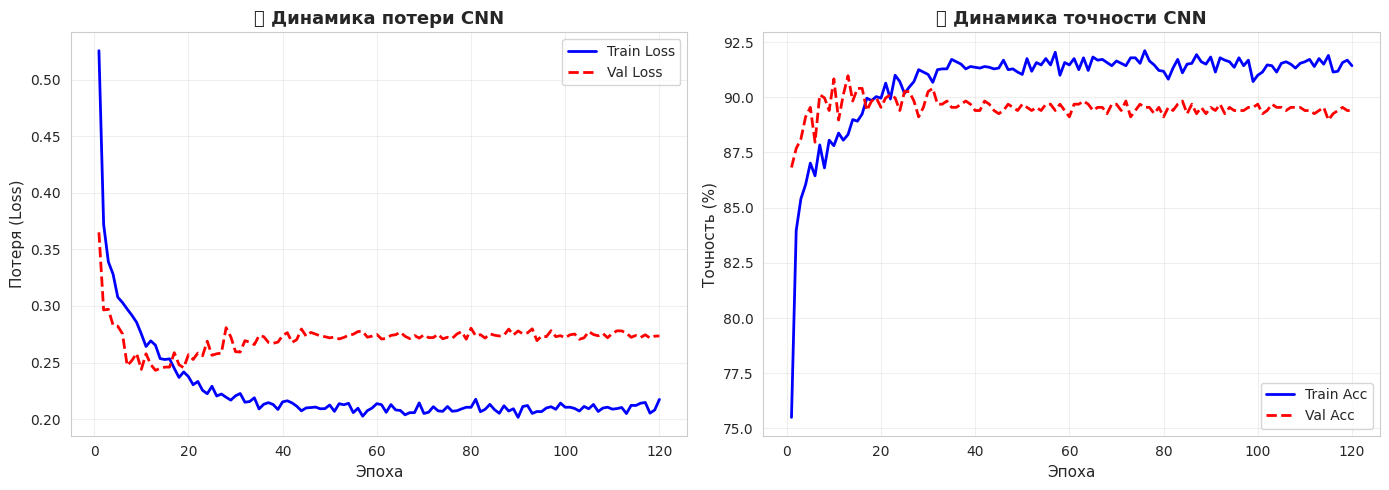

💾 График сохранён: results/CNN_XGB_120epochs_16batch_0.00051lr_20260420_145538/CNN_XGB_120epochs_16batch_0.00051lr_20260420_145538_cnn_training_plot.png

🗂️ Confusion Matrix:
[[386  41]
 [ 31 240]]


/tmp/ipykernel_57233/1339107128.py:23: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_57233/1339107128.py:26: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.savefig(cm_save_path, dpi=300, bbox_inches='tight')
/home/strel/miniconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


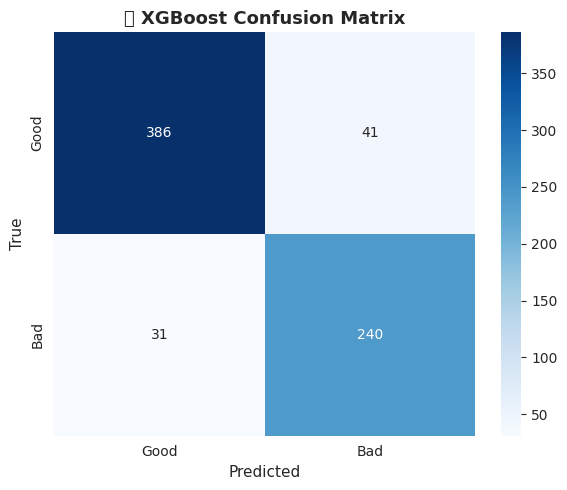

💾 Матрица ошибок сохранена: results/CNN_XGB_120epochs_16batch_0.00051lr_20260420_145538/CNN_XGB_120epochs_16batch_0.00051lr_20260420_145538_confusion_matrix.png
💾 Текстовый отчёт сохранён: results/CNN_XGB_120epochs_16batch_0.00051lr_20260420_145538/CNN_XGB_120epochs_16batch_0.00051lr_20260420_145538_classification_report.txt
💾 Модель XGBoost сохранена: results/CNN_XGB_120epochs_16batch_0.00051lr_20260420_145538/CNN_XGB_120epochs_16batch_0.00051lr_20260420_145538_xgboost_model.json
💾 Веса CNN сохранены: results/CNN_XGB_120epochs_16batch_0.00051lr_20260420_145538/CNN_XGB_120epochs_16batch_0.00051lr_20260420_145538_cnn_weights.pth
💾 Конфигурация сохранена: results/CNN_XGB_120epochs_16batch_0.00051lr_20260420_145538/CNN_XGB_120epochs_16batch_0.00051lr_20260420_145538_config.json

📁 ВСЕ ФАЙЛЫ СОХРАНЕНЫ В ПАПКУ:
   /mnt/d/Универ/ВКР/Код/ПарсингДаных/DataTransform/scientificProject/results/CNN_XGB_120epochs_16batch_0.00051lr_20260420_145538

📄 Список сохранённых файлов:
   1. CNN_XGB_120epoch

In [22]:
# ============================================
# 📈 СОХРАНЕНИЕ РЕЗУЛЬТАТОВ
# ============================================
from datetime import datetime
import json

# 📊 Строим графики обучения CNN
print("\n📈 Строим графики обучения CNN...")
plot_training_history(history, results_dir, folder_prefix, save_name='cnn_training_plot.png')

# 🗂️ Матрица ошибок XGBoost
cm = confusion_matrix(y_val, y_pred)
print("\n🗂️ Confusion Matrix:")
print(cm)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Good', 'Bad'],
            yticklabels=['Good', 'Bad'])
plt.xlabel('Predicted', fontsize=11)
plt.ylabel('True', fontsize=11)
plt.title('🎯 XGBoost Confusion Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()

cm_save_path = results_dir / f"{folder_prefix}_confusion_matrix.png"
plt.savefig(cm_save_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"💾 Матрица ошибок сохранена: {cm_save_path}")

# 📄 Сохраняем текстовый отчёт
report_path = results_dir / f"{folder_prefix}_classification_report.txt"
with open(report_path, 'w', encoding='utf-8') as f:
    f.write("="*60 + "\n")
    f.write(f"CNN + XGBoost Classification Report\n")
    f.write(f"Date: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
    f.write("="*60 + "\n\n")
    f.write(f"CNN Parameters:\n")
    f.write(f"  - Epochs: {EPOCHS}\n")
    f.write(f"  - Batch Size: {BATCH_SIZE}\n")
    f.write(f"  - Learning Rate: {LEARNING_RATE}\n")
    f.write(f"  - Best CNN Val Acc: {best_val_acc:.2f}%\n\n")
    f.write(f"XGBoost Parameters:\n")
    f.write(f"  - Estimators: 400\n")
    f.write(f"  - Max Depth: 8\n")
    f.write(f"  - Learning Rate: 0.05\n\n")
    f.write("Classification Report:\n")
    f.write(classification_report(y_val, y_pred, target_names=['Good', 'Bad']))
    f.write("\nConfusion Matrix:\n")
    f.write(str(cm))
    f.write(f"\n\nROC-AUC: {roc_auc_score(y_val, y_proba):.4f}\n")

print(f"💾 Текстовый отчёт сохранён: {report_path}")

# 💾 Сохраняем модель XGBoost
xgb_model_path = results_dir / f"{folder_prefix}_xgboost_model.json"
xgb_model.save_model(xgb_model_path)
print(f"💾 Модель XGBoost сохранена: {xgb_model_path}")

# 💾 Сохраняем веса CNN
cnn_model_path = results_dir / f"{folder_prefix}_cnn_weights.pth"
torch.save(model_full.state_dict(), cnn_model_path)
print(f"💾 Веса CNN сохранены: {cnn_model_path}")

# 📄 Сохраняем конфигурацию эксперимента
config = {
    'cnn_epochs': EPOCHS,
    'batch_size': BATCH_SIZE,
    'cnn_learning_rate': LEARNING_RATE,
    'embedding_dim': 64,
    'xgb_estimators': 400,
    'xgb_max_depth': 8,
    'xgb_learning_rate': 0.05,
    'best_cnn_val_acc': best_val_acc,
    'roc_auc': roc_auc_score(y_val, y_proba),
    'train_samples': len(X_train),
    'val_samples': len(X_val),
    'input_features': X_train_combined.shape[1],
    'timestamp': datetime.now().isoformat(),
    'device': str(DEVICE)
}

config_path = results_dir / f"{folder_prefix}_config.json"
with open(config_path, 'w', encoding='utf-8') as f:
    json.dump(config, f, indent=2, ensure_ascii=False)

print(f"💾 Конфигурация сохранена: {config_path}")

# ============================================
# 📋 ИТОГОВАЯ ИНФОРМАЦИЯ
# ============================================

print("\n" + "="*60)
print("📁 ВСЕ ФАЙЛЫ СОХРАНЕНЫ В ПАПКУ:")
print(f"   {results_dir.absolute()}")
print("\n📄 Список сохранённых файлов:")
print(f"   1. {folder_prefix}_cnn_weights.pth (веса CNN)")
print(f"   2. {folder_prefix}_xgboost_model.json (модель XGBoost)")
print(f"   3. {folder_prefix}_cnn_training_plot.png (графики обучения CNN)")
print(f"   4. {folder_prefix}_confusion_matrix.png (матрица ошибок XGBoost)")
print(f"   5. {folder_prefix}_classification_report.txt (отчёт)")
print(f"   6. {folder_prefix}_config.json (параметры эксперимента)")
print("="*60)
